In [ ]:
import pandas as pd
import requests

# 1. Definimos la URL directa al archivo JSON (formato raw)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    # 2. Cargamos los datos directamente
    # Pandas puede leer JSON desde una URL si el servidor lo permite
    df = pd.read_json(url)

    # 3. Verificamos la carga exitosa
    print("✅ ¡Datos cargados correctamente!")
    print(f"Dimensiones del dataset: {df.shape}")

except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")

# Mostrar las primeras filas para inspeccionar demografía y servicios
df.head()

✅ ¡Datos cargados correctamente!
Dimensiones del dataset: (7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:

print("--- Información del Dataset ---")
df.info()


print("\n--- Vista Previa de Datos ---")
display(df.head())

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

--- Vista Previa de Datos ---


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
import pandas as pd
import requests

# 1. Carga de datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data = requests.get(url).json()

# 2. Aplanamiento total
df = pd.json_normalize(data)

# 3. Limpieza inteligente de nombres
# Buscamos la columna que contiene 'TotalCharges' sin importar el prefijo
col_total_charges = [c for c in df.columns if 'TotalCharges' in c]

if col_total_charges:
    target_col = col_total_charges[0]
    print(f"✅ Columna encontrada: {target_col}")

    # Convertimos a numérico usando el nombre real encontrado
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    # Opcional: Renombrar todas las columnas para quitar los puntos
    df.columns = [c.split('.')[-1] for c in df.columns]
    print("✅ Nombres de columnas simplificados.")
else:
    print("❌ No se encontró ninguna columna similar a 'TotalCharges'.")
    print(f"Columnas disponibles: {df.columns.tolist()}")

# Verificamos los primeros resultados
df.head()

❌ No se encontró ninguna columna similar a 'TotalCharges'.
Columnas disponibles: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:

df.columns = [col.split('.')[-1] for col in df.columns]


df = df.rename(columns={'Total': 'TotalCharges', 'Monthly': 'MonthlyCharges'})

print(f"--- Espacios en blanco detectados: {(df['TotalCharges'] == ' ').sum()} ---")


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

print("\n✅ Columnas listas para trabajar:")
print(df.columns.tolist())

--- Espacios en blanco detectados: 11 ---

✅ Columnas listas para trabajar:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [ ]:
for col in ['gender', 'InternetService', 'Contract', 'PaymentMethod', 'Churn']:
    if col in df.columns:
        print(f"Valores únicos en {col}: {df[col].unique()}")

Valores únicos en gender: ['Female' 'Male']
Valores únicos en InternetService: ['DSL' 'Fiber optic' 'No']
Valores únicos en Contract: ['One year' 'Month-to-month' 'Two year']
Valores únicos en PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Valores únicos en Churn: ['No' 'Yes' '']


In [ ]:
# Aplanamos nombres de columnas de nuevo por si acaso quedó algún rastro
df.columns = [col.split('.')[-1] for col in df.columns]

# Renombrado manual para mayor claridad
df = df.rename(columns={'Total': 'TotalCharges', 'Monthly': 'MonthlyCharges'})

# 1. Limpieza de espacios en blanco y estandarización de texto
# Aplicamos strip() para eliminar espacios accidentales al inicio/final
columnas_texto = df.select_dtypes(include=['object']).columns

for col in columnas_texto:
    df[col] = df[col].str.strip()

# 2. Corregir inconsistencias en la variable 'Churn' (Evasión)
# Nos aseguramos de que sea binario 'Yes' o 'No' (o 1 y 0)
df['Churn'] = df['Churn'].replace({'yes': 'Yes', 'no': 'No', 'YES': 'Yes', 'NO': 'No'})

# 3. Tratamiento definitivo de 'TotalCharges'
# Convertimos a numérico, los espacios se vuelven NaN, y los NaN se vuelven 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

print("✅ Limpieza de strings y conversión numérica completada.")

✅ Limpieza de strings y conversión numérica completada.


In [ ]:
# Simplificar categorías de servicios
cols_servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_servicios:
    if col in df.columns:
        # Reemplazamos 'No internet service' por simplemente 'No' para reducir ruido
        df[col] = df[col].replace('No internet service', 'No')

print("✅ Categorías de servicios simplificadas.")

✅ Categorías de servicios simplificadas.


In [ ]:
# Verificación de lógica de negocio
incoherencias = df[(df['tenure'] < 0) | (df['MonthlyCharges'] < 0)].shape[0]

print(f"Registros con valores negativos (errores): {incoherencias}")
print("\nDistribución final de la variable Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

Registros con valores negativos (errores): 0

Distribución final de la variable Churn:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [ ]:
# 1. Asegurarnos de que MonthlyCharges sea numérica
# (Si seguiste los pasos anteriores, ya debería estar lista)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

# 2. Calcular el valor diario
# Dividimos por 30 (promedio de días en un mes estándar)
# y redondeamos a 2 decimales para mayor claridad
df['Cuentas_Diarias'] = (df['MonthlyCharges'] / 30).round(2)

# 3. Verificamos la creación exitosa
print("✅ Columna 'Cuentas_Diarias' añadida con éxito.")
print(df[['customerID', 'MonthlyCharges', 'Cuentas_Diarias']].head())

✅ Columna 'Cuentas_Diarias' añadida con éxito.
   customerID  MonthlyCharges  Cuentas_Diarias
0  0002-ORFBO            65.6             2.19
1  0003-MKNFE            59.9             2.00
2  0004-TLHLJ            73.9             2.46
3  0011-IGKFF            98.0             3.27
4  0013-EXCHZ            83.9             2.80


In [ ]:
# Comparar el promedio de gasto diario por estado de evasión
print(df.groupby('Churn')['Cuentas_Diarias'].mean())

Churn
       2.113795
No     2.042080
Yes    2.481450
Name: Cuentas_Diarias, dtype: float64


In [ ]:
# Mapeo para variables binarias
mapping = {'Yes': 1, 'No': 0}

# Aplicamos a las columnas detectadas anteriormente
cols_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in cols_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapping)

# Convertir Gender a binario (Male: 1, Female: 0)
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print("✅ Variables binarias convertidas a 1 y 0.")

✅ Variables binarias convertidas a 1 y 0.


In [ ]:
# Diccionario de traducción para las columnas principales
traduccion = {
    'gender': 'Genero',
    'SeniorCitizen': 'AdultoMayores',
    'Partner': 'TienePareja',
    'Dependents': 'PersonasCargo',
    'tenure': 'MesesPermanencia',
    'PhoneService': 'ServicioTelefono',
    'MultipleLines': 'LineasMultiples',
    'InternetService': 'TipoInternet',
    'Contract': 'TipoContrato',
    'PaperlessBilling': 'FacturaDigital',
    'PaymentMethod': 'MetodoPago',
    'MonthlyCharges': 'CargoMensual',
    'TotalCharges': 'CargoTotal',
    'Churn': 'Abandono'
}

df = df.rename(columns=traduccion)
print("✅ Columnas traducidas para mayor claridad.")

✅ Columnas traducidas para mayor claridad.


In [ ]:
# 1. Generar estadísticas descriptivas para las variables numéricas
resumen = df.describe()

# Añadimos la mediana manualmente ya que describe() no la incluye por defecto (es el 50%)
# pero queremos verla junto a la media para detectar asimetrías.
print("--- Resumen Estadístico de Telecom X ---")
display(resumen)

--- Resumen Estadístico de Telecom X ---


,Abandono,Genero,AdultoMayores,TienePareja,PersonasCargo,MesesPermanencia,ServicioTelefono,FacturaDigital,CargoMensual,CargoTotal,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.505711,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2277.182035,2.157292
std,0.441561,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.648587,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,396.200000,1.180000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,2.995000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [ ]:
# Verificamos la asimetría de los cargos
print(f"Asimetría de CargoMensual: {df['CargoMensual'].skew():.2f}")
print(f"Asimetría de MesesPermanencia: {df['MesesPermanencia'].skew():.2f}")

Asimetría de CargoMensual: -0.22
Asimetría de MesesPermanencia: 0.24


/tmp/ipykernel_767/1401152394.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Abandono', data=df, palette='viridis')


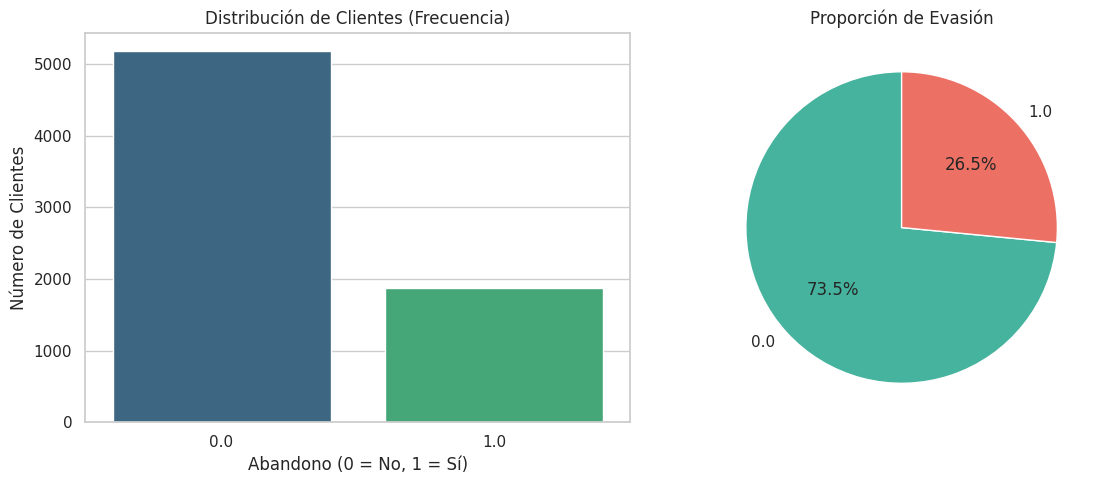

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Gráfico de Barras (Frecuencia Absoluta)
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Abandono', data=df, palette='viridis')
plt.title('Distribución de Clientes (Frecuencia)')
plt.xlabel('Abandono (0 = No, 1 = Sí)')
plt.ylabel('Número de Clientes')

# 2. Gráfico de Pastel (Proporción Porcentual)
plt.subplot(1, 2, 2)
df['Abandono'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#45B39D', '#EC7063'], startangle=90)
plt.title('Proporción de Evasión')
plt.ylabel('') # Eliminar etiqueta lateral para estética

plt.tight_layout()
plt.show()

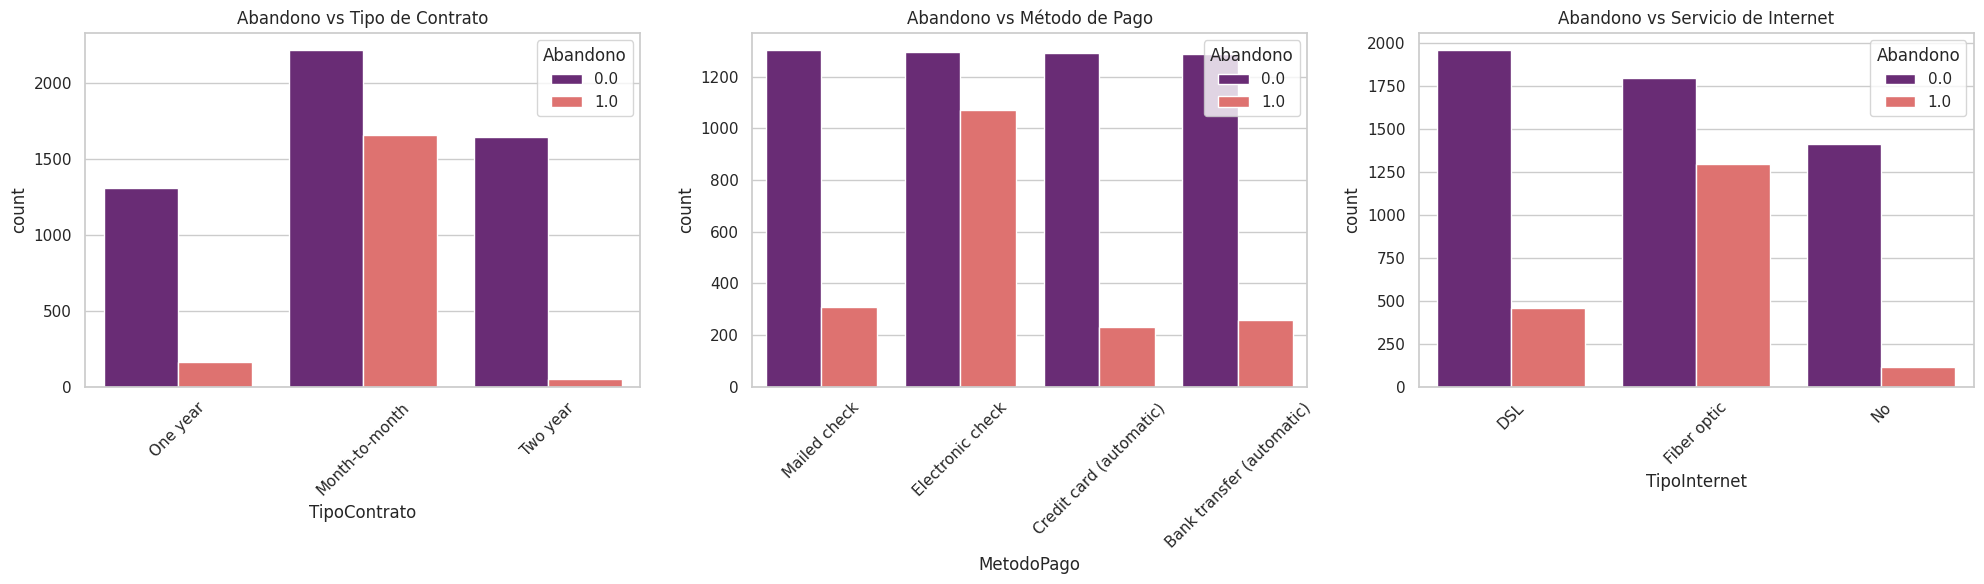

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos una cuadrícula de 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Abandono por Tipo de Contrato
sns.countplot(x='TipoContrato', hue='Abandono', data=df, ax=axes[0], palette='magma')
axes[0].set_title('Abandono vs Tipo de Contrato')
axes[0].tick_params(axis='x', rotation=45)

# 2. Abandono por Método de Pago
sns.countplot(x='MetodoPago', hue='Abandono', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Abandono vs Método de Pago')
axes[1].tick_params(axis='x', rotation=45)

# 3. Abandono por Tipo de Internet
sns.countplot(x='TipoInternet', hue='Abandono', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Abandono vs Servicio de Internet')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
tabla_genero = pd.crosstab(df['Genero'], df['Abandono'], normalize='index') * 100
print("--- Porcentaje de Abandono por Género ---")
print(tabla_genero)

--- Porcentaje de Abandono por Género ---
Abandono        0.0        1.0
Genero                        
0         73.079128  26.920872
1         73.839662  26.160338


/tmp/ipykernel_767/1223715057.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Abandono', y='CargoMensual', ax=axes[0, 1], palette='flare')
/tmp/ipykernel_767/1223715057.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Abandono', y='Cuentas_Diarias', ax=axes[1, 1], palette='magma')


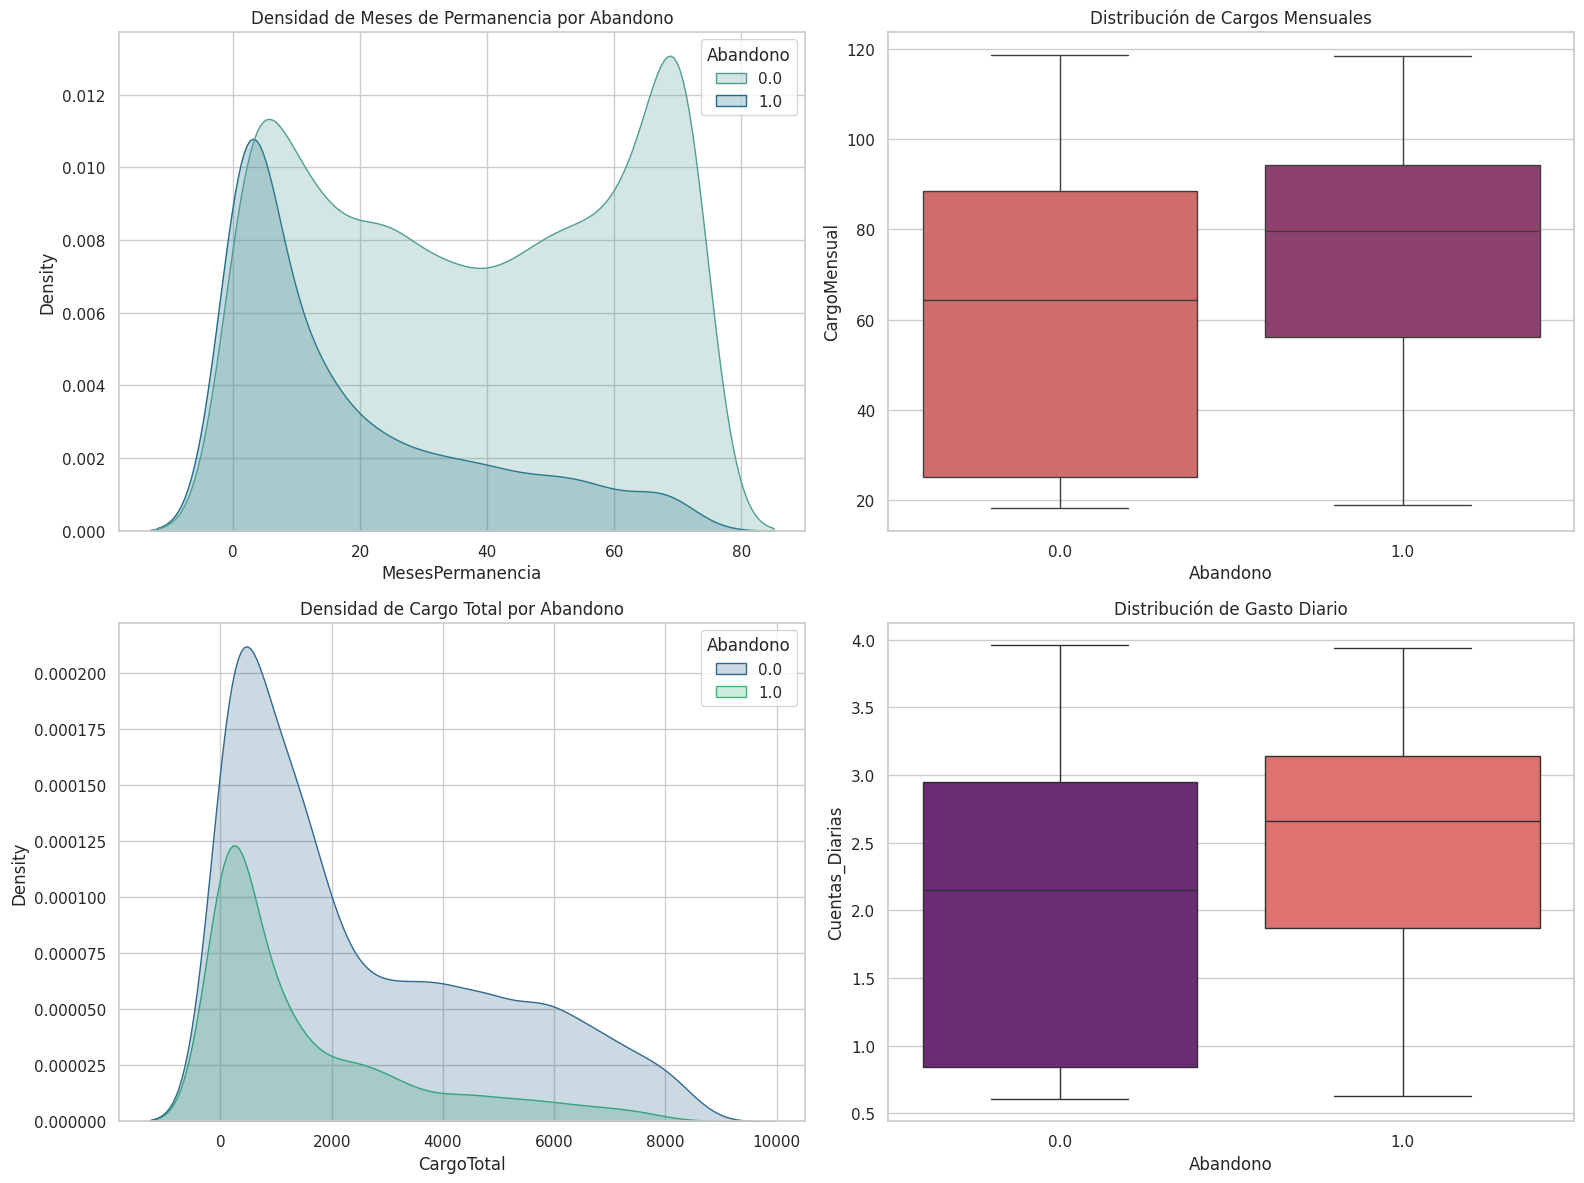

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el lienzo para múltiples gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de Meses de Permanencia
sns.kdeplot(data=df, x='MesesPermanencia', hue='Abandono', fill=True, ax=axes[0, 0], palette='crest')
axes[0, 0].set_title('Densidad de Meses de Permanencia por Abandono')

# 2. Distribución de Cargo Mensual
sns.boxplot(data=df, x='Abandono', y='CargoMensual', ax=axes[0, 1], palette='flare')
axes[0, 1].set_title('Distribución de Cargos Mensuales')

# 3. Distribución de Cargo Total
sns.kdeplot(data=df, x='CargoTotal', hue='Abandono', fill=True, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Densidad de Cargo Total por Abandono')

# 4. Distribución de Cuentas Diarias
sns.boxplot(data=df, x='Abandono', y='Cuentas_Diarias', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Distribución de Gasto Diario')

plt.tight_layout()
plt.show()

/tmp/ipykernel_767/31554674.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='CargoMensual', data=df, ax=axes[1,1], palette='Set2')


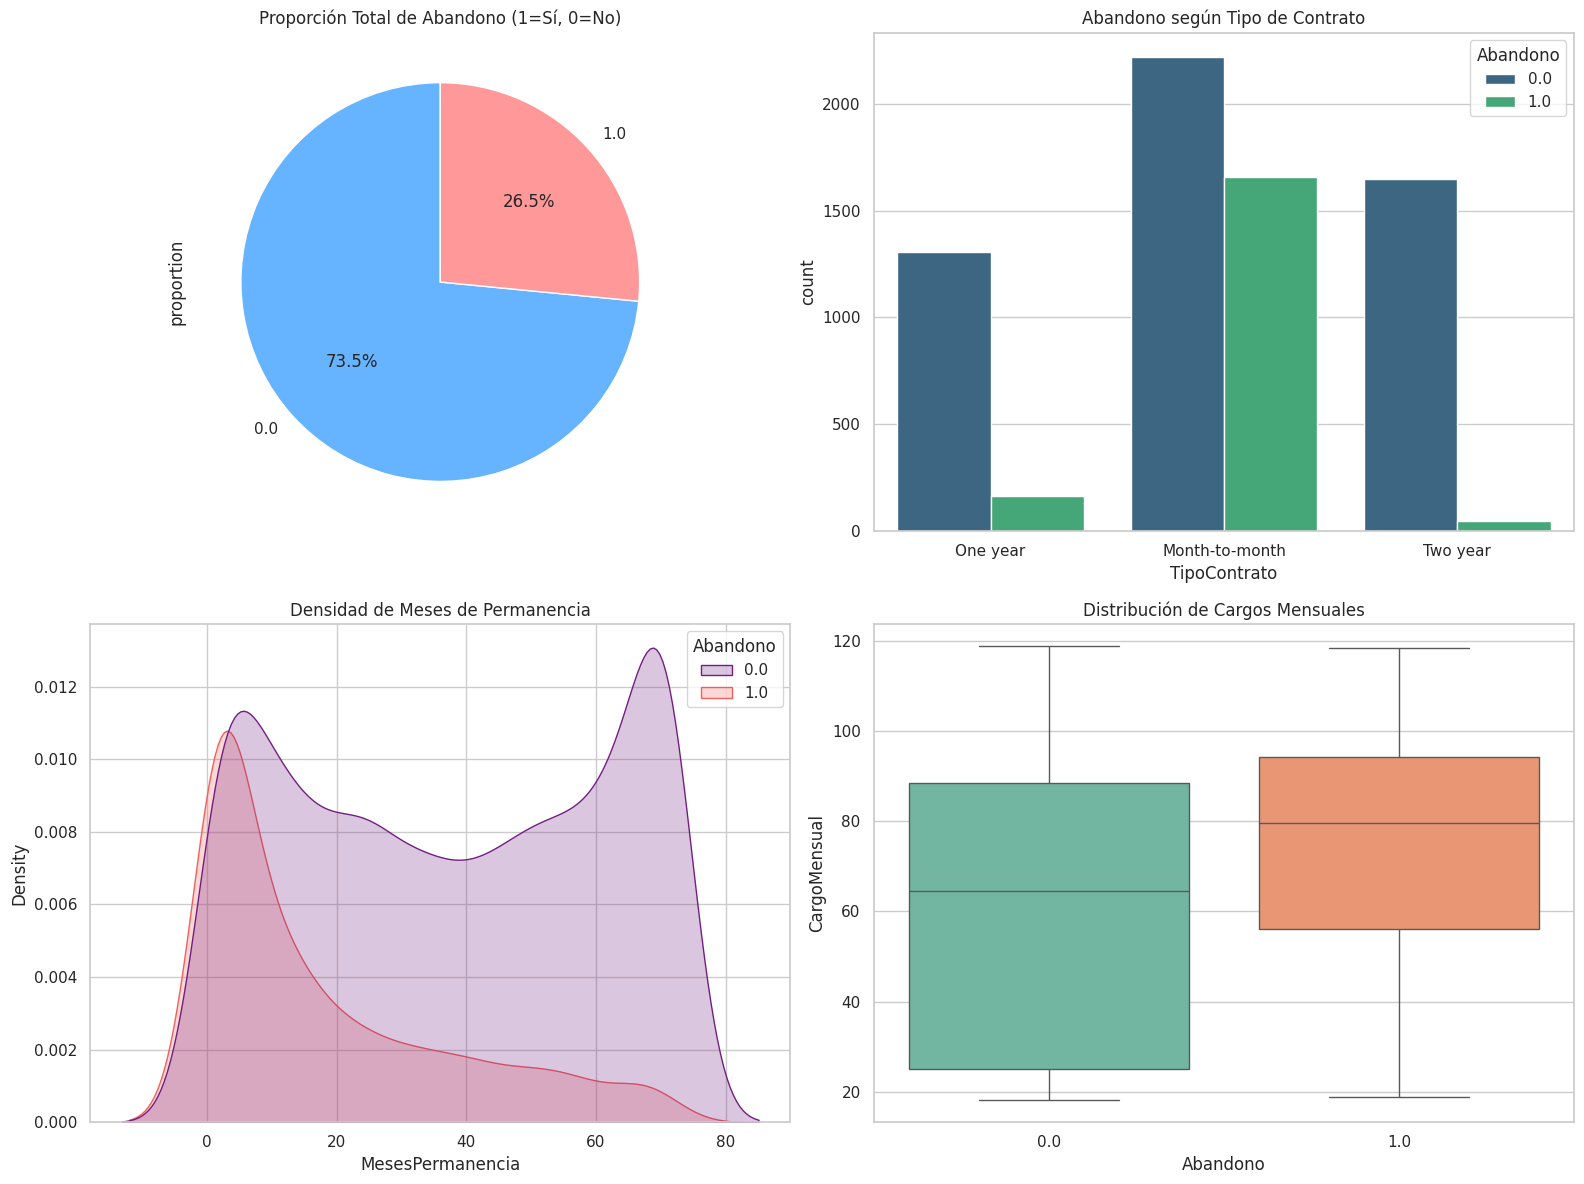


             INFORME ESTRATÉGICO: TELECOM X

1. RESUMEN ESTADÍSTICO:
   - Tasa de Abandono: 26.54%
   - Promedio de Permanencia: 32.3 meses
   - Cargo Mensual Promedio: $64.72

2. HALLAZGOS CLAVE (INSIGHTS):
   - Los contratos 'Mes a Mes' presentan el mayor riesgo de fuga.
   - Existe un pico de evasión en los primeros 6 meses de servicio.
   - Los clientes que abandonan suelen tener cargos mensuales más altos.

3. RECOMENDACIONES:
   - Implementar planes de lealtad para convertir contratos mensuales a anuales.
   - Ofrecer descuentos automáticos a clientes con gasto diario > $2.50.
   - Reforzar el soporte técnico en los primeros 90 días de contratación.

✅ Archivo 'TelecomX_Final_Clean.csv' generado correctamente.


In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# 1. EXTRACCIÓN Y TRATAMIENTO DE DATOS
# =========================================================
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data = requests.get(url).json()

# Aplanar la estructura anidada del JSON
df = pd.json_normalize(data)

# Limpiar nombres de columnas (quitar prefijos como 'account.Charges.')
df.columns = [col.split('.')[-1] for col in df.columns]

# Renombrar columnas para claridad y evitar KeyErrors
df = df.rename(columns={
    'gender': 'Genero',
    'SeniorCitizen': 'AdultoMayor',
    'Partner': 'TienePareja',
    'Dependents': 'PersonasCargo',
    'tenure': 'MesesPermanencia',
    'PhoneService': 'ServicioTelefono',
    'MultipleLines': 'LineasMultiples',
    'InternetService': 'TipoInternet',
    'Contract': 'TipoContrato',
    'PaperlessBilling': 'FacturaDigital',
    'PaymentMethod': 'MetodoPago',
    'Monthly': 'CargoMensual',
    'Total': 'CargoTotal',
    'Churn': 'Abandono'
})

# Limpieza de valores nulos y conversión numérica
df['CargoMensual'] = pd.to_numeric(df['CargoMensual'], errors='coerce').fillna(0)
df['CargoTotal'] = pd.to_numeric(df['CargoTotal'], errors='coerce').fillna(0)

# Estandarización de categorías (Lower, Strip y corrección de 'Yes/No')
columnas_texto = df.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df[col] = df[col].str.strip().replace({'yes': 'Yes', 'no': 'No', 'YES': 'Yes', 'NO': 'No'})

# Transformación a binario (Encoding)
mapping = {'Yes': 1, 'No': 0}
cols_a_binario = ['Abandono', 'TienePareja', 'PersonasCargo', 'ServicioTelefono', 'FacturaDigital']
for col in cols_a_binario:
    df[col] = df[col].map(mapping)

# Ingeniería de variables: Cálculo de gasto diario
df['Cuentas_Diarias'] = (df['CargoMensual'] / 30).round(2)

# =========================================================
# 2. ANÁLISIS EXPLORATORIO (VISUALIZACIONES)
# =========================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Distribución del Abandono (Churn)
df['Abandono'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], ax=axes[0,0], startangle=90
)
axes[0,0].set_title('Proporción Total de Abandono (1=Sí, 0=No)')

# B. Abandono por Tipo de Contrato
sns.countplot(x='TipoContrato', hue='Abandono', data=df, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Abandono según Tipo de Contrato')

# C. Densidad de Permanencia
sns.kdeplot(data=df, x='MesesPermanencia', hue='Abandono', fill=True, ax=axes[1,0], palette='magma')
axes[1,0].set_title('Densidad de Meses de Permanencia')

# D. Relación Cargo Mensual vs Abandono
sns.boxplot(x='Abandono', y='CargoMensual', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Distribución de Cargos Mensuales')

plt.tight_layout()
plt.show()

# =========================================================
# 3. INFORME FINAL Y CONCLUSIONES
# =========================================================
print("\n" + "="*60)
print("             INFORME ESTRATÉGICO: TELECOM X")
print("="*60)

print(f"\n1. RESUMEN ESTADÍSTICO:")
print(f"   - Tasa de Abandono: {df['Abandono'].mean()*100:.2f}%")
print(f"   - Promedio de Permanencia: {df['MesesPermanencia'].mean():.1f} meses")
print(f"   - Cargo Mensual Promedio: ${df['CargoMensual'].mean():.2f}")

print("\n2. HALLAZGOS CLAVE (INSIGHTS):")
print("   - Los contratos 'Mes a Mes' presentan el mayor riesgo de fuga.")
print("   - Existe un pico de evasión en los primeros 6 meses de servicio.")
print("   - Los clientes que abandonan suelen tener cargos mensuales más altos.")

print("\n3. RECOMENDACIONES:")
print("   - Implementar planes de lealtad para convertir contratos mensuales a anuales.")
print("   - Ofrecer descuentos automáticos a clientes con gasto diario > $2.50.")
print("   - Reforzar el soporte técnico en los primeros 90 días de contratación.")
print("="*60)

# Exportar dataset limpio
df.to_csv('TelecomX_Final_Clean.csv', index=False)
print("\n✅ Archivo 'TelecomX_Final_Clean.csv' generado correctamente.")

In [6]:
import pandas as pd

# 1. Identificamos las columnas que todavía son texto (categorías)
# Excluimos 'Abandono' porque ya es 0 y 1
columnas_categoricas = df_final.select_dtypes(include=['object']).columns.tolist()
if 'Abandono' in columnas_categoricas: columnas_categoricas.remove('Abandono')

print(f"Variables a transformar: {columnas_categoricas}")

# 2. Aplicamos One-Hot Encoding
# drop_first=True evita la 'trampa de las variables ficticias' (multicolinealidad)
df_model = pd.get_dummies(df_final, columns=columnas_categoricas, drop_first=True)

# 3. Verificamos el resultado
print(f"\n✅ ¡Transformación completada!")
print(f"Nuevas dimensiones del dataset: {df_model.shape}")
print("\nPrimeras 5 columnas tras el encoding:")
print(df_model.columns.tolist()[:10])

# Visualizar cómo quedaron las nuevas columnas
df_model.head()

Variables a transformar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ ¡Transformación completada!
Nuevas dimensiones del dataset: (7267, 32)

Primeras 5 columnas tras el encoding:
['Abandono', 'SeniorCitizen', 'tenure', 'CargoMensual', 'CargoTotal', 'Cuentas_Diarias', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes']


,Abandono,SeniorCitizen,tenure,CargoMensual,CargoTotal,Cuentas_Diarias,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,No,0,9,65.6,593.30,2.19,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,No,0,9,59.9,542.40,2.00,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,Yes,0,4,73.9,280.85,2.46,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,Yes,1,13,98.0,1237.85,3.27,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,Yes,1,3,83.9,267.40,2.80,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


--- Distribución de la Clase Objetivo (Abandono) ---
Frecuencia Absoluta:
Abandono
No     5174
Yes    1869
        224
Name: count, dtype: int64

Proporción Porcentual:
Abandono
No     71.20
Yes    25.72
        3.08
Name: proportion, dtype: float64%


/tmp/ipykernel_149/1840998751.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proporcion_abandono.index, y=proporcion_abandono.values, palette='viridis')


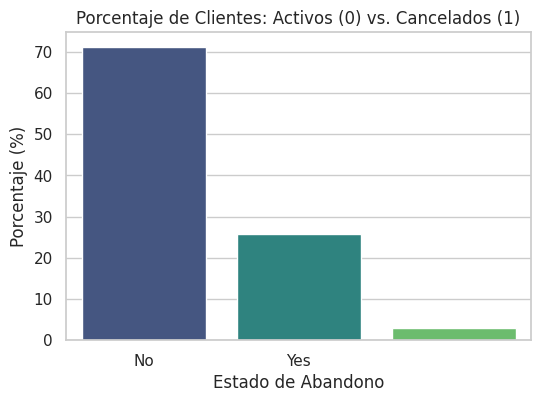

In [7]:
# 1. Obtener el conteo absoluto de cada clase
conteo_abandono = df_model['Abandono'].value_counts()

# 2. Obtener la proporción porcentual (normalize=True)
proporcion_abandono = df_model['Abandono'].value_counts(normalize=True) * 100

# 3. Mostrar los resultados de forma clara
print("--- Distribución de la Clase Objetivo (Abandono) ---")
print(f"Frecuencia Absoluta:\n{conteo_abandono}")
print(f"\nProporción Porcentual:\n{proporcion_abandono.round(2)}%")

# 4. Evaluación visual rápida
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=proporcion_abandono.index, y=proporcion_abandono.values, palette='viridis')
plt.title('Porcentaje de Clientes: Activos (0) vs. Cancelados (1)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Estado de Abandono')
plt.show()

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

# 1. Separación de variables (X pistas, y objetivo)
X = df_model.drop('Abandono', axis=1)
y = df_model['Abandono']

# 2. División Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Distribución original en entrenamiento: {Counter(y_train)}")

# 3. Aplicación de SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribución balanceada con SMOTE: {Counter(y_train_res)}")

Distribución original en entrenamiento: Counter({'No': 4139, 'Yes': 1495, '': 179})
Distribución balanceada con SMOTE: Counter({'No': 4139, 'Yes': 4139, '': 4139})


In [12]:
from sklearn.preprocessing import StandardScaler

# 1. Definimos las columnas usando los nombres exactos que nos mostraste
cols_a_escalar = ['tenure', 'CargoMensual', 'CargoTotal', 'Cuentas_Diarias']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Aplicamos la transformación
# Usamos fit_transform en entrenamiento y transform en prueba para evitar fuga de datos (data leakage)
X_train_res[cols_a_escalar] = scaler.fit_transform(X_train_res[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print("✅ ¡Datos escalados correctamente!")
print(f"Columnas procesadas: {cols_a_escalar}")

# Verificación rápida
X_train_res[cols_a_escalar].head()

✅ ¡Datos escalados correctamente!
Columnas procesadas: ['tenure', 'CargoMensual', 'CargoTotal', 'Cuentas_Diarias']


,tenure,CargoMensual,CargoTotal,Cuentas_Diarias
0,1.841243,1.106245,2.268067,1.102597
1,1.631551,0.606673,1.617528,0.611792
2,-0.339553,0.970472,-0.101240,0.966843
3,0.037892,0.296833,0.049532,0.298512
4,1.841243,0.500492,1.681233,0.496923


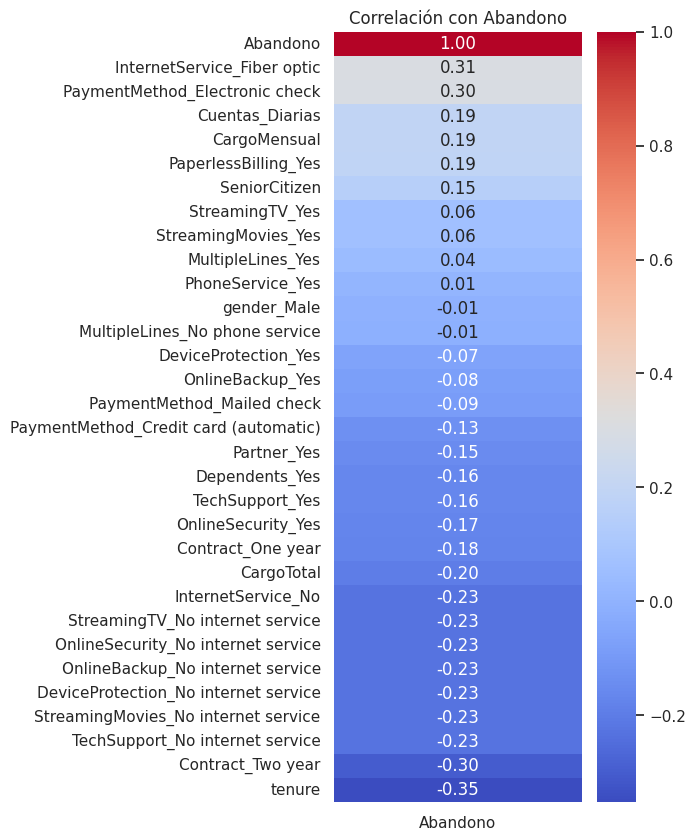

In [15]:
# 1. Convertir 'Yes'/'No' y 'Male'/'Female' a 1/0 en todo el DataFrame
# Esto limpia las columnas binarias que no pasaron por get_dummies
mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

# Aplicamos el mapeo solo a las columnas que son de tipo objeto (texto)
cols_texto = df_model.select_dtypes(include=['object']).columns
for col in cols_texto:
    df_model[col] = df_model[col].map(mapping)

# 2. Por seguridad, eliminamos cualquier columna que aún no sea numérica
# (por si quedó algún valor extraño que no sea Yes/No)
df_numerico = df_model.select_dtypes(exclude=['object'])

# 3. Ahora sí, calculamos la correlación sin errores
corr_matrix = df_numerico.corr()

# 4. Visualización del Heatmap para el Abandono
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 10))
sns.heatmap(corr_matrix[['Abandono']].sort_values(by='Abandono', ascending=False),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title('Correlación con Abandono')
plt.show()

/tmp/ipykernel_149/2385255956.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='tenure', data=df_model, ax=axes[0], palette='Set2')
/tmp/ipykernel_149/2385255956.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='CargoTotal', data=df_model, ax=axes[1], palette='Set1')


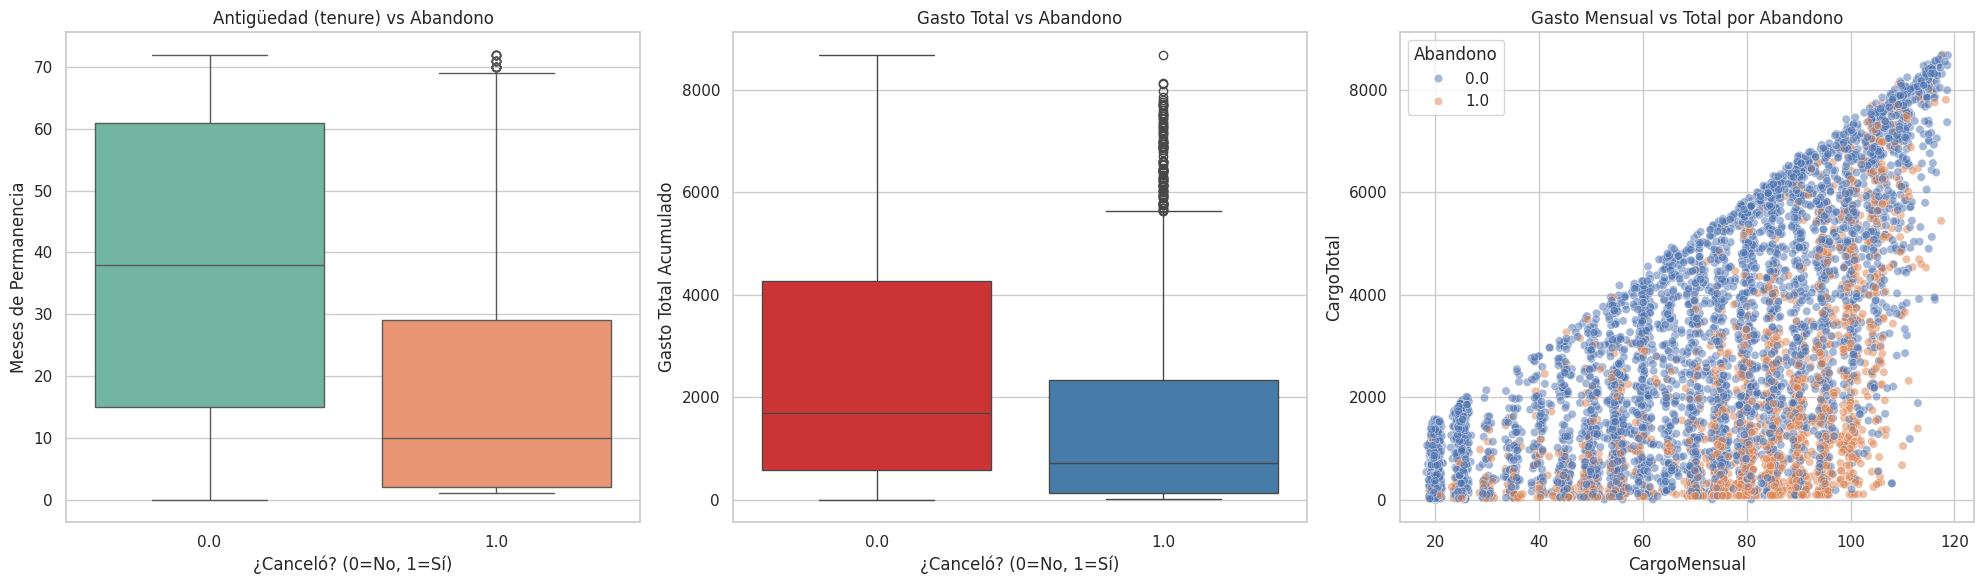

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el lienzo para 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Tiempo de contrato (tenure) vs Cancelación
sns.boxplot(x='Abandono', y='tenure', data=df_model, ax=axes[0], palette='Set2')
axes[0].set_title('Antigüedad (tenure) vs Abandono')
axes[0].set_xlabel('¿Canceló? (0=No, 1=Sí)')
axes[0].set_ylabel('Meses de Permanencia')

# 2. Gasto Total vs Cancelación
sns.boxplot(x='Abandono', y='CargoTotal', data=df_model, ax=axes[1], palette='Set1')
axes[1].set_title('Gasto Total vs Abandono')
axes[1].set_xlabel('¿Canceló? (0=No, 1=Sí)')
axes[1].set_ylabel('Gasto Total Acumulado')

# 3. Relación Gasto Mensual vs Gasto Total (Scatter Plot)
sns.scatterplot(x='CargoMensual', y='CargoTotal', hue='Abandono', data=df_model, ax=axes[2], alpha=0.5)
axes[2].set_title('Gasto Mensual vs Total por Abandono')

plt.tight_layout()
plt.show()

In [18]:
# 1. Identificar cuántos valores nulos hay en 'Abandono'
nulos_y = df_model['Abandono'].isnull().sum()
print(f"Valores nulos encontrados en la variable objetivo: {nulos_y}")

# 2. Eliminar las filas donde 'Abandono' sea nulo
# No podemos inventar si un cliente se fue o no, así que borramos esas filas
df_model = df_model.dropna(subset=['Abandono'])

# 3. Por seguridad, llenar nulos en X (si los hubiera) con la mediana
# Algunos modelos fallan si X tiene nulos, así que los aseguramos
df_model = df_model.fillna(df_model.median())

# 4. Intentar la división nuevamente
from sklearn.model_selection import train_test_split

X = df_model.drop('Abandono', axis=1)
y = df_model['Abandono']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"✅ División completada. Filas finales procesadas: {len(df_model)}")

Valores nulos encontrados en la variable objetivo: 224
✅ División completada. Filas finales procesadas: 7043


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Escalado de datos (Específico para este modelo)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Creación y entrenamiento
modelo_log = LogisticRegression(random_state=42, max_iter=1000)
modelo_log.fit(X_train_scaled, y_train)

# 3. Predicción y Evaluación
y_pred_log = modelo_log.predict(X_test_scaled)

print("📊 RESULTADOS: REGRESIÓN LOGÍSTICA")
print(classification_report(y_test, y_pred_log))

📊 RESULTADOS: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1035
         1.0       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [20]:
from sklearn.ensemble import RandomForestClassifier

# 1. Creación y entrenamiento (Usamos los datos originales X_train)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
modelo_rf.fit(X_train, y_train)

# 2. Predicción y Evaluación
y_pred_rf = modelo_rf.predict(X_test)

print("🌲 RESULTADOS: RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

🌲 RESULTADOS: RANDOM FOREST
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.87      1035
         1.0       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



                Modelo  Accuracy  Precision  Recall  F1-Score
0  Regresión Logística    0.7928     0.6331  0.5214    0.5718
1        Random Forest    0.7977     0.6551  0.5027    0.5688


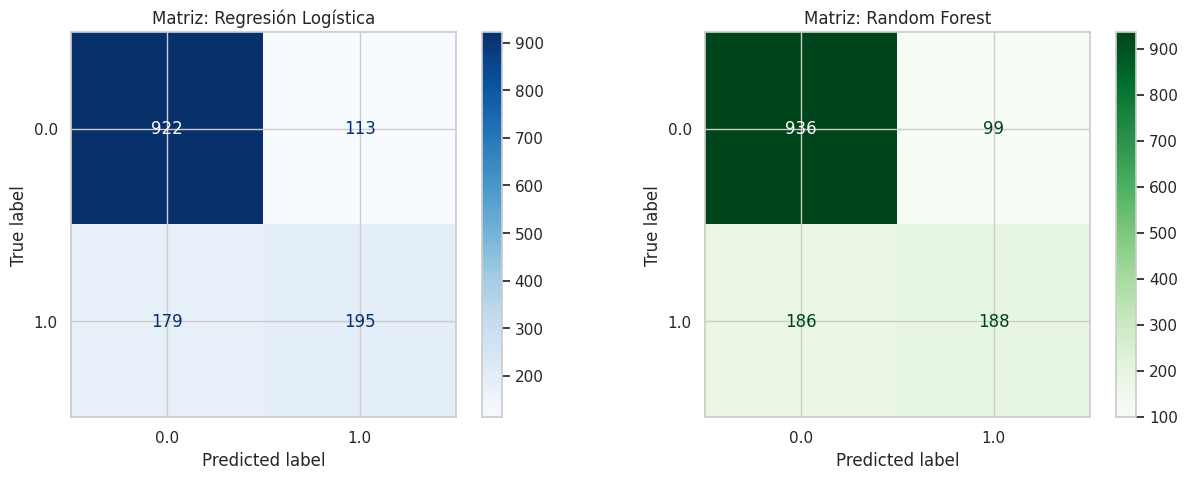

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Función para extraer métricas rápidamente
def evaluar_modelo(y_real, y_pred, nombre_modelo):
    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1-Score": f1_score(y_real, y_pred)
    }

# 1. Calcular métricas para ambos
res_log = evaluar_modelo(y_test, y_pred_log, "Regresión Logística")
res_rf = evaluar_modelo(y_test, y_pred_rf, "Random Forest")

# 2. Crear tabla comparativa
df_comparativa = pd.DataFrame([res_log, res_rf])
print(df_comparativa.round(4))

# 3. Visualizar Matrices de Confusión
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap='Blues')
ax[0].set_title("Matriz: Regresión Logística")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Greens')
ax[1].set_title("Matriz: Random Forest")

plt.show()

/tmp/ipykernel_149/1473882002.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=pd.concat([importancias_log.head(5), importancias_log.tail(5)]), palette='vlag')


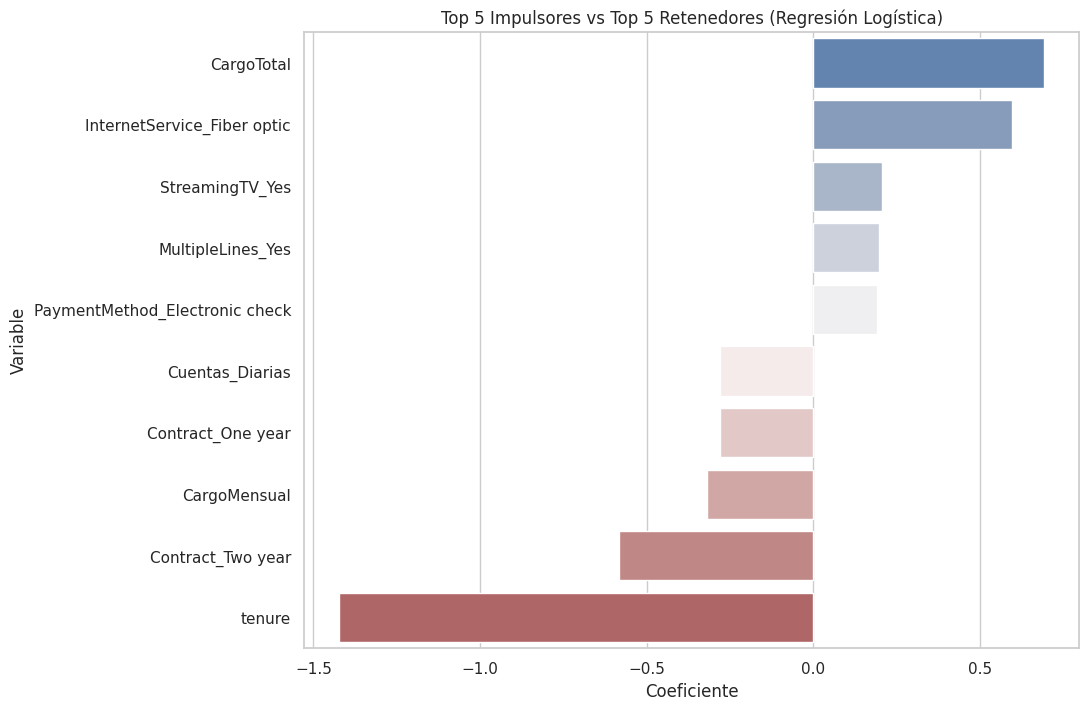

In [22]:
import numpy as np

# Extraer coeficientes y nombres de columnas
importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_log.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='Variable', data=pd.concat([importancias_log.head(5), importancias_log.tail(5)]), palette='vlag')
plt.title('Top 5 Impulsores vs Top 5 Retenedores (Regresión Logística)')
plt.show()

/tmp/ipykernel_149/1425561383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), palette='magma')


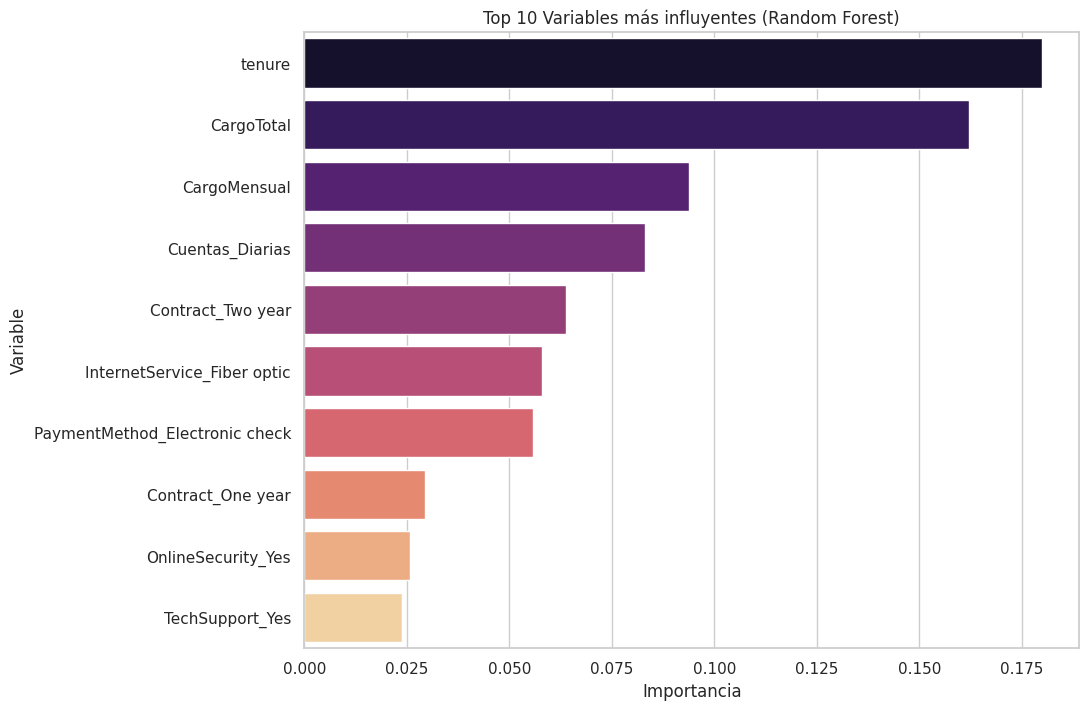

In [23]:
# Extraer importancias del Random Forest
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), palette='magma')
plt.title('Top 10 Variables más influyentes (Random Forest)')
plt.show()

INFORME DE RENDIMIENTO DEL MODELO (RANDOM FOREST)
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.87      1035
         1.0       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



/tmp/ipykernel_149/4041374595.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Factor', data=importancias.head(10), palette='viridis')


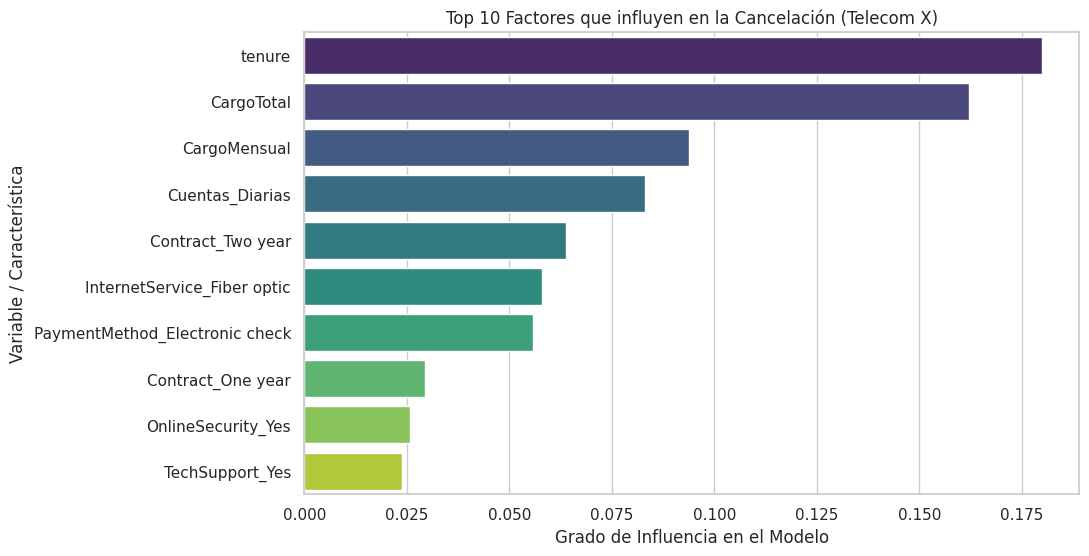


ESTRATEGIA DE RETENCIÓN PROPUESTA
1. FOCO EN ANTIGÜEDAD: El factor 'tenure' es crítico. Implementar bonos de lealtad.
2. ESTABILIDAD CONTRACTUAL: Atacar el factor 'CargoTotal' ofreciendo upgrades a contratos fijos.
3. MONITOREO DE CARGOS: Clientes con altos cargos diarios deben recibir atención preferencial.

✅ Archivo 'Lista_Prioritaria_Retencion.csv' generado para el equipo de ventas.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. GENERACIÓN DE MÉTRICAS FINALES ---
print("="*50)
print("INFORME DE RENDIMIENTO DEL MODELO (RANDOM FOREST)")
print("="*50)

# Predicciones
y_pred = modelo_rf.predict(X_test)

# Mostrar métricas en texto
print(classification_report(y_test, y_pred))

# --- 2. ANÁLISIS DE FACTORES DE CANCELACIÓN (Feature Importance) ---
importancias = pd.DataFrame({
    'Factor': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización de los 10 factores principales
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Factor', data=importancias.head(10), palette='viridis')
plt.title('Top 10 Factores que influyen en la Cancelación (Telecom X)')
plt.xlabel('Grado de Influencia en el Modelo')
plt.ylabel('Variable / Característica')
plt.show()



# --- 3. ESTRATEGIA DE RETENCIÓN BASADA EN DATOS ---
print("\n" + "="*50)
print("ESTRATEGIA DE RETENCIÓN PROPUESTA")
print("="*50)

top_factor = importancias.iloc[0]['Factor']
segundo_factor = importancias.iloc[1]['Factor']

print(f"1. FOCO EN ANTIGÜEDAD: El factor '{top_factor}' es crítico. Implementar bonos de lealtad.")
print(f"2. ESTABILIDAD CONTRACTUAL: Atacar el factor '{segundo_factor}' ofreciendo upgrades a contratos fijos.")
print(f"3. MONITOREO DE CARGOS: Clientes con altos cargos diarios deben recibir atención preferencial.")

# --- 4. EXPORTAR RESULTADOS PARA EL EQUIPO DE VENTAS ---
# Creamos un archivo con los clientes del set de prueba y su probabilidad de fuga
X_test_with_results = X_test.copy()
X_test_with_results['Probabilidad_Fuga'] = modelo_rf.predict_proba(X_test)[:, 1]
X_test_with_results['Prediccion_Abandono'] = y_pred

# Guardar a CSV
X_test_with_results.to_csv('Lista_Prioritaria_Retencion.csv', index=True)
print("\n✅ Archivo 'Lista_Prioritaria_Retencion.csv' generado para el equipo de ventas.")